# APEC Personalization Impact — Reactivation Analysis Across All Client States

## What this notebook answers

Does receiving an APEC (personalized) marketing send relate to a different
reactivation rate than receiving a non-personalized send? This notebook checks
that question across **three client lifecycle states** — Lapsed, Dormant,
and Dormant 3+ years — rather than a single population, and adds a
**business line** cut (Women's, Men's, Kids) as a second, independent lens.

This is an **observational comparison of existing send history**, not a
randomized experiment. It shows what's *associated* with reactivation
historically across these populations — useful context on its own, and a
sanity check before committing to any live test.

The analysis has four parts:
1. **Part 1 — APEC vs. non-APEC, by client state.** The primary comparison,
   run separately for each of the three lifecycle states. Transactional/
   account-service email is excluded from both sides, since receiving one
   isn't a marketing choice.
2. **Part 2 — Full campaign-category breakdown, by client state.** APEC
   alongside the other major campaign families (Dynamic Shoppable Email,
   Freestyle Lifecycle Series, transactional/account-service email, and
   everything else), for context on where reactivation concentrates within
   each state. Also includes a full-window-vs-per-month view, since some
   categories resend to the same clients far more often than others.
3. **Part 3 — Business line.** The same two comparisons (APEC vs. non-APEC,
   and the full category breakdown, with its own full-window-vs-per-month
   view), cut by business line instead of client state, pooling all three
   lifecycle states together.
4. **Category trend over time.** OTHER, DSE, APEC, and FLS plotted together
   month by month — once with all client states pooled, and once split into
   one panel per client state — to see whether each category's trend, and
   its ranking relative to the others, holds up consistently over the
   analysis window rather than being driven by a single month or state.

## Client lifecycle states in scope

| State | Definition (days since last checkout, as of the send) |
|---|---|
| Lapsed | 121–365 days |
| Dormant | 366–1,095 days |
| Dormant 3+ yrs | > 1,095 days |

Clients with `client_state_detail = 'Never Active'` (no checkout, ever) are
excluded throughout — a client who has never checked out cannot "reactivate."
A client's state is evaluated **as of each specific send**, not as of today,
so a client who moved between states over the analysis window is correctly
bucketed for each send they received.

**Active clients (≤ 120 days since last checkout) are out of scope.**
`curated.client_reactivation_demand_events` only logs a demand event for a
client returning from Lapsed or Dormant — it has no rows for Active
clients, so this metric can't measure their conversion at all.

## Campaign categories: how sends are classified

Campaigns are classified from the sent campaign's name (`send_utm_campaign`
on the Blueshift send data), using pattern matching rather than a verified
per-send flag, since no such flag exists in the data available. A send is
assigned to the first category it matches, checked in this order:

| Category | What it captures |
|---|---|
| **APEC** | Algorithmic Personalized Email Content — campaign names containing "apec", plus its confirmed browse-abandon win-back triggers, StylePass onboarding messages, and style-profile reactivation pushes. This mapping is validated directly against `apec_setup_doc.xlsx` (included in this project), a reference list of ~2,200 actual APEC job configurations — every name in that list matches one of these four patterns. |
| **TRANSACTIONAL** | Any campaign name containing "transactional" — account-service email (password resets, order/Fix status confirmations, account alerts) that a client only receives because they're already taking an action on their account. Excluded entirely from Part 1 and 3's APEC/non-APEC comparisons; shown only as its own category in Part 2/3's full breakdown, for transparency, not as a marketing lever to rank against the others. |
| **DSE** | Dynamic Shoppable Email campaigns, including their TFY and CYL content variants. |
| **FLS** | Freestyle Lifecycle Series — behaviorally triggered reminders sent after a high-intent event (cart abandonment, a saved item still available or newly on sale), identified by an explicit "freestyle-lifecycle" naming convention. A one-time mass reactivation offer test that shares this naming (campaign names containing "offertest") is routed to OTHER instead, ahead of the FLS check, since it isn't a behavioral trigger. |
| **OTHER** | Everything else — generic marketing, seasonal, and win-back campaigns with no personalization-suggestive naming, plus the one-time offer test above. |

**Caveats carried over from the reference mapping:**
- DSE and FLS are each a distinct, confirmed campaign program, not a naming
  guess — but neither uses APEC's personalization approach, so their results
  are context on the broader campaign landscape, not evidence about APEC
  specifically.
- TRANSACTIONAL's high reactivation rate reflects a client's own
  already-in-progress return (e.g. resetting a password to log back in), not
  something the send itself caused — it should never be read as a
  "top-performing campaign type."
- The FLS/OTHER boundary is name-based and imperfect: Freestyle-branded
  content that references clothing themes but lacks the explicit
  "freestyle-lifecycle" identifier falls into OTHER, since it can't be
  reliably distinguished from generic marketing copy by name alone.

## Business lines in scope

Women's, Men's, and Kids, sourced directly from `curated.client.business_line`
(joined by `client_id`) — a client-level field, not inferred from campaign
naming. Note: `apec_setup_doc.xlsx`'s job-configuration list contains **zero**
Kids-targeted campaigns under any of the four APEC-matching patterns above —
structurally, APEC volume in the Kids business line is expected to be
negligible or zero. That's a fact about which campaigns exist, not a data gap
in this notebook.

## Reactivation metric: session/UTM-attributed

A client is counted as **reactivated** by a send if:
1. They visited the site or app via a session carrying UTM parameters
   matching that specific send (real click-through evidence), **and**
2. That session is linked to a real demand event — a Fix request or a
   direct-buy order — within 7 days of the send.

This is a conservative, lower-bound standard: it misses reactivations that
happen through untracked paths (e.g., closing an email and returning later
with no tracked link), so observed rates here understate true reactivation
rather than precisely counting it. The same metric and 7-day window is used
identically across every part of this notebook, so all comparisons are on
equal footing.

**Data recency:** the tables this metric relies on may take time to fully
reflect a send's outcome. To avoid comparing groups using data that hasn't
finished settling, this analysis excludes very recent sends and only looks at
a window of history old enough to have stabilized.

In [1]:
import time

import pandas as pd
import matplotlib.pyplot as plt
from amphibian import get_data_accessor
from statsmodels.stats.proportion import proportion_confint, confint_proportions_2indep, test_proportions_2indep

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

def query(sql, max_attempts=4, retry_delay_seconds=20):
    # The longer queries in this notebook occasionally hit a transient connection
    # drop (network/VPN blip, not a query bug -- the same query succeeds on retry).
    for attempt in range(1, max_attempts + 1):
        try:
            return get_data_accessor(engines=['presto']).fetch_sql(sql=sql, error_on_empty=False)
        except Exception as e:
            if attempt == max_attempts:
                raise
            print(f"query() attempt {attempt}/{max_attempts} failed ({type(e).__name__}: {e}); retrying in {retry_delay_seconds}s...")
            time.sleep(retry_delay_seconds)

# Population thresholds (days since last checkout)
ACTIVE_MAX_DAYS = 120  # clients at or under this are Active -- excluded from this analysis entirely (see intro)
LAPSED_MAX_DAYS = 365
DORMANT_3YR_MIN_DAYS = 1095

LIFECYCLE_STATES = ['Lapsed', 'Dormant', 'Dormant 3+ yrs']
BUSINESS_LINES = ('Womens', 'Mens', 'Kids')

# Send history window (same window used throughout, so every part is comparable)
START_DATE = '2025-01-01'
END_DATE = '2026-05-31'  # hardcoded for idempotent results -- last day of a full month, so no partial month

# Reactivation metric
SESSION_ATTRIBUTION_WINDOW_DAYS = 7  # a session must land within this many days of the send to count as a match

# Statistics
ALPHA = 0.05

# Chart colors -- validated categorical palette (fixed hue per category, used consistently across every chart)
GROUP_COLORS = {
    'non-APEC':      '#2a78d6',  # blue
    'APEC':          '#e34948',  # red
}
CATEGORY_COLORS = {
    'OTHER':         '#eda100',  # yellow
    'TRANSACTIONAL': '#7a7a7a',  # neutral grey -- not a marketing category, kept visually distinct
    'DSE':           '#008300',  # green
    'APEC':          '#e34948',  # red
    'FLS':           '#4a3aa7',  # violet
}
CATEGORY_ORDER = ['OTHER', 'TRANSACTIONAL', 'DSE', 'APEC', 'FLS']

print(f"Analysis window: {START_DATE} to {END_DATE}")

Analysis window: 2025-01-01 to 2026-05-31


## Step 1 — How many clients are we talking about?

Before comparing campaign types, a sanity check on the population itself: how
many clients fall into each lifecycle state today.

In [2]:
lifecycle_bucket_query = f"""--sql
WITH journal AS (
    SELECT
        client_id,
        client_state_detail,
        date_diff('day', date(last_buyable_checkout_ts), current_date) AS days_since_last_checkout
    FROM curated.checkout_based_client_state_journal
    WHERE is_current = 1
)
SELECT
    CASE
        WHEN client_state_detail = 'Never Active' THEN 'Never Active'
        WHEN days_since_last_checkout <= {LAPSED_MAX_DAYS} THEN 'Lapsed'
        WHEN days_since_last_checkout <= {DORMANT_3YR_MIN_DAYS} THEN 'Dormant'
        ELSE 'Dormant 3+ yrs'
    END AS lifecycle_bucket,
    COUNT(*) AS n_clients
FROM journal
WHERE client_state_detail = 'Never Active' OR days_since_last_checkout > {ACTIVE_MAX_DAYS} -- Active clients are out of scope (see intro)
GROUP BY 1
ORDER BY n_clients DESC
"""

lifecycle_bucket_df = query(lifecycle_bucket_query)
lifecycle_bucket_df

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,lifecycle_bucket,n_clients
0,Never Active,37158690
1,Dormant 3+ yrs,9929139
2,Dormant,2057567
3,Lapsed,903367


## Step 2 — The shared logic behind every part below

Parts 1 and 2 run the same four-step logic, just grouped differently (by
lifecycle state, then by category):

1. **Find eligible sends**: sends to clients who were not `Never Active` or
   `Active` *at the time of the send*, bucketed into Lapsed / Dormant /
   Dormant 3+ yrs as of that send (not just today).
2. **Categorize each send** by its campaign name, per the categories
   described above.
3. **Match to a session**: did the client visit via a session carrying this
   send's UTM parameters, within `SESSION_ATTRIBUTION_WINDOW_DAYS`?
4. **Confirm demand**: did that session link to an actual Fix request or
   direct-buy order?

Part 3 reuses the identical logic, but groups by business line instead of
lifecycle state, pooling all three states together.

Each client is counted once per group (e.g., once for APEC, once for
non-APEC, if they received both) — a client who received multiple sends in
the same group is only counted as reactivated once, not once per send.

## Part 1 — APEC vs. non-APEC, by client state

The primary comparison: does receiving an APEC (personalized) send relate to
a different reactivation rate than receiving anything else, and does that
answer differ by lifecycle state? Transactional/account-service email is
excluded from the population for this comparison — it isn't a marketing
choice, so it doesn't belong on either side of an APEC-vs-non-APEC split.

In [3]:
apec_by_state_query = f"""--sql
WITH sends AS (
    SELECT client_id, sent_timestamp, send_utm_campaign, send_utm_content
    FROM blueshift.campaign_activity_kpis
    WHERE execution_date >= DATE '{START_DATE}'
      AND execution_date <= DATE '{END_DATE}'
      AND holdout_group = 0 -- only include clients who were actually sent the campaign, not just targeted
      AND send_utm_campaign NOT LIKE '%transactional%' -- exclude account-service email; not a marketing choice
),
state_at_send AS (
    -- client's lifecycle state AS OF the send, not just today
    SELECT
        s.client_id, s.sent_timestamp, s.send_utm_campaign, s.send_utm_content,
        CASE
            WHEN j.client_state_detail = 'Never Active' THEN 'Never Active'
            WHEN date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) <= {ACTIVE_MAX_DAYS} THEN 'Active'
            WHEN date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) <= {LAPSED_MAX_DAYS} THEN 'Lapsed'
            WHEN date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) <= {DORMANT_3YR_MIN_DAYS} THEN 'Dormant'
            ELSE 'Dormant 3+ yrs'
        END AS lifecycle_state
    FROM sends s
    INNER JOIN curated.checkout_based_client_state_journal j
        ON s.client_id = j.client_id
        AND s.sent_timestamp >= j.start_timestamp
        AND s.sent_timestamp <  j.end_timestamp
),
eligible_sends AS (
    SELECT * FROM state_at_send WHERE lifecycle_state NOT IN ('Never Active', 'Active')
),
categorized_sends AS (
    SELECT
        client_id, sent_timestamp, send_utm_content, lifecycle_state,
        CASE
            WHEN send_utm_campaign LIKE '%apec%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%browseabandon%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%stylepass%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%styleprofile%' THEN 'APEC'
            ELSE 'non-APEC'
        END AS apec_group
    FROM eligible_sends
),
matched_sessions AS (
    -- did the client visit via a session carrying this send's UTM parameters?
    SELECT c.client_id, c.sent_timestamp, c.lifecycle_state, c.apec_group, u.active_session_id
    FROM categorized_sends c
    INNER JOIN curated.user_session_conversion_metrics u
        ON u.client_id = c.client_id
        AND u.utm_source = 'blueshift'
        AND u.utm_content = c.send_utm_content
        AND u.datetime_in_utc >= c.sent_timestamp -- the session must occur after the send, but not too long after
        AND u.datetime_in_utc <  c.sent_timestamp + INTERVAL '{SESSION_ATTRIBUTION_WINDOW_DAYS}' DAY
    WHERE u.date_in_utc >= DATE '{START_DATE}'
),
attributed_demand AS (
    -- did that session lead to a real Fix or direct-buy demand event?
    SELECT DISTINCT ms.client_id, ms.sent_timestamp, ms.lifecycle_state, ms.apec_group
    FROM matched_sessions ms
    INNER JOIN curated.client_reactivation_demand_events e
        ON e.active_session_id = ms.active_session_id
    WHERE e.demand_type IN ('fix', 'direct_buy')
),
client_group AS (
    -- one row per client per state per group: did they reactivate at all under this group
    SELECT
        d.client_id, d.lifecycle_state, d.apec_group,
        MAX(CASE WHEN a.client_id IS NOT NULL THEN 1 ELSE 0 END) AS client_reactivated
    FROM categorized_sends d
    LEFT JOIN attributed_demand a
        ON d.client_id = a.client_id
        AND d.sent_timestamp = a.sent_timestamp
        AND d.lifecycle_state = a.lifecycle_state
        AND d.apec_group = a.apec_group
    GROUP BY 1, 2, 3
)
SELECT
    lifecycle_state,
    apec_group,
    COUNT(DISTINCT client_id) AS unique_clients_sent,
    SUM(client_reactivated) AS reactivated_clients,
    CAST(SUM(client_reactivated) AS DOUBLE) / COUNT(DISTINCT client_id) AS client_reactivation_rate
FROM client_group
GROUP BY 1, 2
ORDER BY 1, 2
"""

apec_by_state_df = query(apec_by_state_query)
apec_by_state_df

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


query() attempt 1/4 failed (ConnectionError: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))); retrying in 20s...


/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


query() attempt 2/4 failed (ConnectionError: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))); retrying in 20s...


/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,lifecycle_state,apec_group,unique_clients_sent,reactivated_clients,client_reactivation_rate
0,Dormant,APEC,1128490,6158,0.005457
1,Dormant,non-APEC,2594787,32501,0.012525
2,Dormant 3+ yrs,APEC,1349279,2512,0.001862
3,Dormant 3+ yrs,non-APEC,4308183,13211,0.003066
4,Lapsed,APEC,717750,3167,0.004412
5,Lapsed,non-APEC,2247197,58000,0.025810


In [4]:
def summarize_apec_vs_non_apec(df, group_col, group_order, alpha=ALPHA):
    # Wilson CIs per group, plus a Wald diff test (non-APEC minus APEC) per group.
    # A group with zero qualifying sends on one side (e.g. Kids has no APEC-classified
    # sends -- see limitations) reports what's available rather than failing.
    rows = []
    for group_val in group_order:
        g = df[df[group_col] == group_val]
        if g.empty:
            continue
        apec_g = g[g['apec_group'] == 'APEC']
        non_apec_g = g[g['apec_group'] == 'non-APEC']

        row = {group_col: group_val}

        if not apec_g.empty:
            apec_row = apec_g.iloc[0]
            apec_ci = proportion_confint(apec_row['reactivated_clients'], apec_row['unique_clients_sent'], alpha=alpha, method='wilson')
            row.update({
                'apec_n': apec_row['unique_clients_sent'],
                'apec_rate': apec_row['client_reactivation_rate'],
                'apec_ci_low': apec_ci[0], 'apec_ci_high': apec_ci[1],
            })
        else:
            row.update({'apec_n': 0, 'apec_rate': float('nan'), 'apec_ci_low': float('nan'), 'apec_ci_high': float('nan')})

        if not non_apec_g.empty:
            non_apec_row = non_apec_g.iloc[0]
            non_apec_ci = proportion_confint(non_apec_row['reactivated_clients'], non_apec_row['unique_clients_sent'], alpha=alpha, method='wilson')
            row.update({
                'non_apec_n': non_apec_row['unique_clients_sent'],
                'non_apec_rate': non_apec_row['client_reactivation_rate'],
                'non_apec_ci_low': non_apec_ci[0], 'non_apec_ci_high': non_apec_ci[1],
            })
        else:
            row.update({'non_apec_n': 0, 'non_apec_rate': float('nan'), 'non_apec_ci_low': float('nan'), 'non_apec_ci_high': float('nan')})

        if not apec_g.empty and not non_apec_g.empty:
            apec_row = apec_g.iloc[0]
            non_apec_row = non_apec_g.iloc[0]
            diff = non_apec_row['client_reactivation_rate'] - apec_row['client_reactivation_rate']
            diff_ci = confint_proportions_2indep(
                non_apec_row['reactivated_clients'], non_apec_row['unique_clients_sent'],
                apec_row['reactivated_clients'], apec_row['unique_clients_sent'],
                compare='diff', method='wald', alpha=alpha,
            )
            test_result = test_proportions_2indep(
                non_apec_row['reactivated_clients'], non_apec_row['unique_clients_sent'],
                apec_row['reactivated_clients'], apec_row['unique_clients_sent'],
                compare='diff', method='wald',
            )
            row.update({
                'diff_non_apec_minus_apec': diff,
                'diff_ci_low': diff_ci[0], 'diff_ci_high': diff_ci[1],
                'p_value': test_result.pvalue,
            })
        else:
            row.update({'diff_non_apec_minus_apec': float('nan'), 'diff_ci_low': float('nan'), 'diff_ci_high': float('nan'), 'p_value': float('nan')})

        rows.append(row)
    return pd.DataFrame(rows)


def print_apec_summary(summary_df, group_col):
    for _, r in summary_df.iterrows():
        print(f"--- {r[group_col]} ---")
        if r['apec_n'] > 0:
            print(f"  APEC:      {r['apec_rate']:.4%}  (95% CI: {r['apec_ci_low']:.4%} - {r['apec_ci_high']:.4%}, n={r['apec_n']:,})")
        else:
            print(f"  APEC:      no qualifying sends observed in this group")
        if r['non_apec_n'] > 0:
            print(f"  non-APEC:  {r['non_apec_rate']:.4%}  (95% CI: {r['non_apec_ci_low']:.4%} - {r['non_apec_ci_high']:.4%}, n={r['non_apec_n']:,})")
        else:
            print(f"  non-APEC:  no qualifying sends observed in this group")
        if r['apec_n'] > 0 and r['non_apec_n'] > 0:
            print(f"  Difference (non-APEC minus APEC): {r['diff_non_apec_minus_apec']:.4%}  (95% CI: {r['diff_ci_low']:.4%} - {r['diff_ci_high']:.4%})")
            print(f"  p-value: {r['p_value']:.2e}")
        else:
            print(f"  Difference/test: not computable -- one side has no qualifying sends")
        print()


apec_by_state_summary = summarize_apec_vs_non_apec(apec_by_state_df, 'lifecycle_state', LIFECYCLE_STATES)
print_apec_summary(apec_by_state_summary, 'lifecycle_state')
apec_by_state_summary

--- Lapsed ---
  APEC:      0.4412%  (95% CI: 0.4262% - 0.4568%, n=717,750)
  non-APEC:  2.5810%  (95% CI: 2.5603% - 2.6018%, n=2,247,197)
  Difference (non-APEC minus APEC): 2.1398%  (95% CI: 2.1140% - 2.1655%)
  p-value: 0.00e+00

--- Dormant ---
  APEC:      0.5457%  (95% CI: 0.5323% - 0.5594%, n=1,128,490)
  non-APEC:  1.2525%  (95% CI: 1.2391% - 1.2662%, n=2,594,787)
  Difference (non-APEC minus APEC): 0.7069%  (95% CI: 0.6877% - 0.7260%)
  p-value: 0.00e+00

--- Dormant 3+ yrs ---
  APEC:      0.1862%  (95% CI: 0.1790% - 0.1936%, n=1,349,279)
  non-APEC:  0.3066%  (95% CI: 0.3015% - 0.3119%, n=4,308,183)
  Difference (non-APEC minus APEC): 0.1205%  (95% CI: 0.1115% - 0.1294%)
  p-value: 2.82e-153



,lifecycle_state,apec_n,apec_rate,apec_ci_low,apec_ci_high,non_apec_n,non_apec_rate,non_apec_ci_low,non_apec_ci_high,diff_non_apec_minus_apec,diff_ci_low,diff_ci_high,p_value
0,Lapsed,717750,0.004412,0.004262,0.004568,2247197,0.025810,0.025603,0.026018,0.021398,0.021140,0.021655,0.000000e+00
1,Dormant,1128490,0.005457,0.005323,0.005594,2594787,0.012525,0.012391,0.012662,0.007069,0.006877,0.007260,0.000000e+00
2,Dormant 3+ yrs,1349279,0.001862,0.001790,0.001936,4308183,0.003066,0.003015,0.003119,0.001205,0.001115,0.001294,2.816677e-153


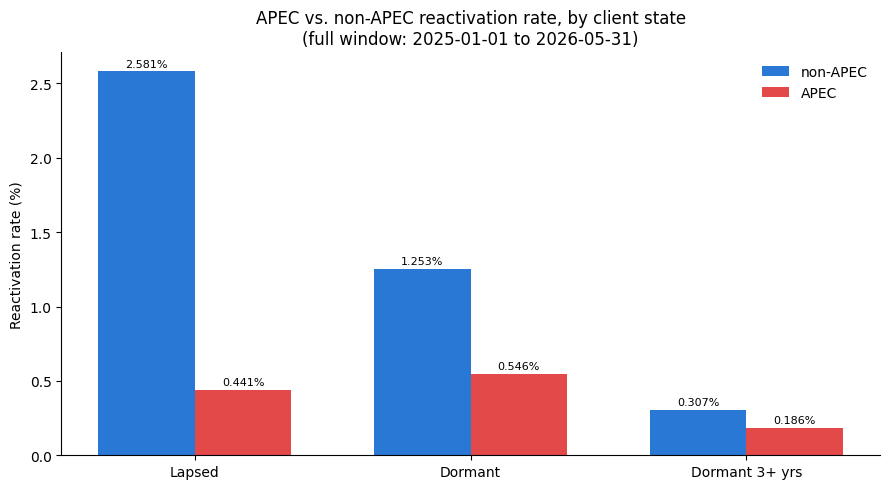

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(LIFECYCLE_STATES))
width = 0.35

non_apec_rates = [apec_by_state_summary.set_index('lifecycle_state').loc[s, 'non_apec_rate'] * 100 for s in LIFECYCLE_STATES]
apec_rates = [apec_by_state_summary.set_index('lifecycle_state').loc[s, 'apec_rate'] * 100 for s in LIFECYCLE_STATES]

bars_non_apec = ax.bar([i - width/2 for i in x], non_apec_rates, width, label='non-APEC', color=GROUP_COLORS['non-APEC'])
bars_apec = ax.bar([i + width/2 for i in x], apec_rates, width, label='APEC', color=GROUP_COLORS['APEC'])

for bars in (bars_non_apec, bars_apec):
    ax.bar_label(bars, fmt='%.3f%%', fontsize=8, padding=2)

ax.set_xticks(list(x))
ax.set_xticklabels(LIFECYCLE_STATES)
ax.set_ylabel('Reactivation rate (%)')
ax.set_title('APEC vs. non-APEC reactivation rate, by client state\n(full window: ' + START_DATE + ' to ' + END_DATE + ')')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### APEC vs. non-APEC, month by month, by client state

The comparison above pools the whole window into one number per state per
group. It's worth also looking at this broken out by month, within each
state — a pooled gap that's actually driven by one or two unusual months
would be a much weaker basis for a conclusion than a gap that shows up
consistently over time.

In [6]:
apec_by_state_monthly_query = f"""--sql
WITH sends AS (
    SELECT client_id, sent_timestamp, send_utm_campaign, send_utm_content
    FROM blueshift.campaign_activity_kpis
    WHERE execution_date >= DATE '{START_DATE}'
      AND execution_date <= DATE '{END_DATE}'
      AND holdout_group = 0
      AND send_utm_campaign NOT LIKE '%transactional%'
),
state_at_send AS (
    SELECT
        s.client_id, s.sent_timestamp, s.send_utm_campaign, s.send_utm_content,
        CASE
            WHEN j.client_state_detail = 'Never Active' THEN 'Never Active'
            WHEN date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) <= {ACTIVE_MAX_DAYS} THEN 'Active'
            WHEN date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) <= {LAPSED_MAX_DAYS} THEN 'Lapsed'
            WHEN date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) <= {DORMANT_3YR_MIN_DAYS} THEN 'Dormant'
            ELSE 'Dormant 3+ yrs'
        END AS lifecycle_state
    FROM sends s
    INNER JOIN curated.checkout_based_client_state_journal j
        ON s.client_id = j.client_id
        AND s.sent_timestamp >= j.start_timestamp
        AND s.sent_timestamp <  j.end_timestamp
),
eligible_sends AS (
    SELECT * FROM state_at_send WHERE lifecycle_state NOT IN ('Never Active', 'Active')
),
categorized_sends AS (
    SELECT
        client_id, sent_timestamp, send_utm_content, lifecycle_state,
        CASE
            WHEN send_utm_campaign LIKE '%apec%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%browseabandon%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%stylepass%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%styleprofile%' THEN 'APEC'
            ELSE 'non-APEC'
        END AS apec_group
    FROM eligible_sends
),
matched_sessions AS (
    SELECT c.client_id, c.sent_timestamp, c.lifecycle_state, c.apec_group, u.active_session_id
    FROM categorized_sends c
    INNER JOIN curated.user_session_conversion_metrics u
        ON u.client_id = c.client_id
        AND u.utm_source = 'blueshift'
        AND u.utm_content = c.send_utm_content
        AND u.datetime_in_utc >= c.sent_timestamp
        AND u.datetime_in_utc <  c.sent_timestamp + INTERVAL '{SESSION_ATTRIBUTION_WINDOW_DAYS}' DAY
    WHERE u.date_in_utc >= DATE '{START_DATE}'
),
attributed_demand AS (
    SELECT DISTINCT ms.client_id, ms.sent_timestamp, ms.lifecycle_state, ms.apec_group
    FROM matched_sessions ms
    INNER JOIN curated.client_reactivation_demand_events e
        ON e.active_session_id = ms.active_session_id
    WHERE e.demand_type IN ('fix', 'direct_buy')
),
client_month_group AS (
    -- one row per client per month per state per group: did they reactivate that month, under this group
    SELECT
        d.client_id,
        DATE_TRUNC('month', d.sent_timestamp) AS month,
        d.lifecycle_state,
        d.apec_group,
        MAX(CASE WHEN a.client_id IS NOT NULL THEN 1 ELSE 0 END) AS client_reactivated
    FROM categorized_sends d
    LEFT JOIN attributed_demand a
        ON d.client_id = a.client_id
        AND d.sent_timestamp = a.sent_timestamp
        AND d.lifecycle_state = a.lifecycle_state
        AND d.apec_group = a.apec_group
    GROUP BY 1, 2, 3, 4
)
SELECT
    month,
    lifecycle_state,
    apec_group,
    COUNT(DISTINCT client_id) AS unique_clients_sent,
    SUM(client_reactivated) AS reactivated_clients,
    CAST(SUM(client_reactivated) AS DOUBLE) / COUNT(DISTINCT client_id) AS client_reactivation_rate
FROM client_month_group
GROUP BY 1, 2, 3
ORDER BY 2, 3, 1
"""

apec_by_state_monthly_df = query(apec_by_state_monthly_query)
apec_by_state_monthly_df['month'] = pd.to_datetime(apec_by_state_monthly_df['month'])
apec_by_state_monthly_df.head()

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,month,lifecycle_state,apec_group,unique_clients_sent,reactivated_clients,client_reactivation_rate
0,2025-01-01,Dormant,APEC,653075,919,0.001407
1,2025-02-01,Dormant,APEC,637274,604,0.000948
2,2025-03-01,Dormant,APEC,631210,542,0.000859
3,2025-04-01,Dormant,APEC,615591,436,0.000708
4,2025-05-01,Dormant,APEC,602610,694,0.001152


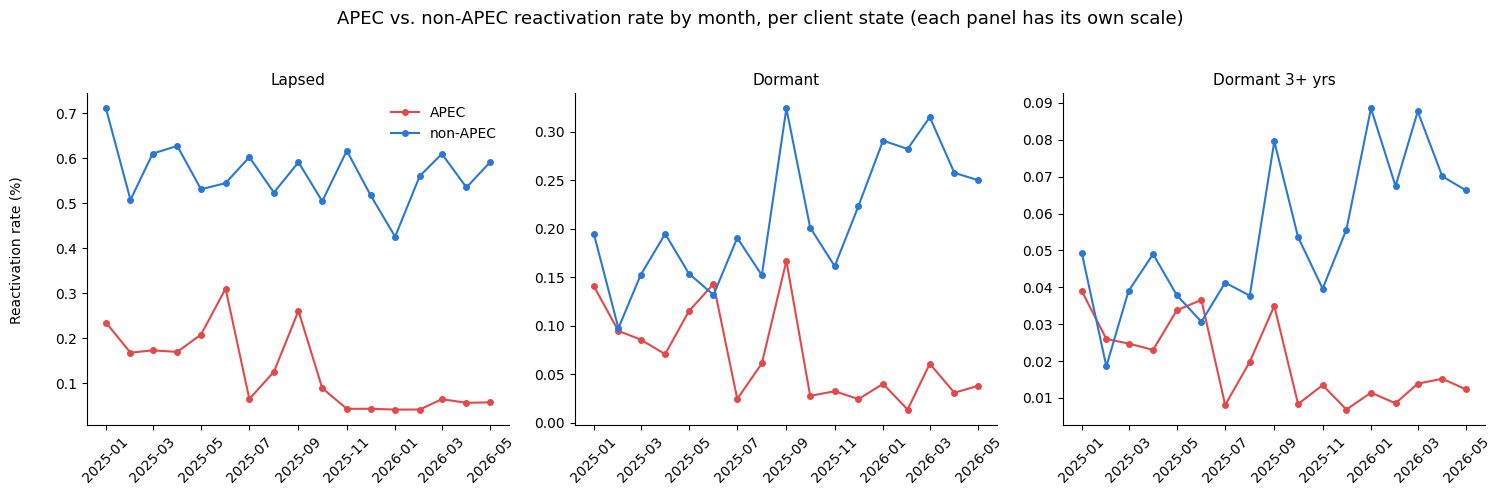

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True)

for i, state in enumerate(LIFECYCLE_STATES):
    ax = axes[i]
    state_df = apec_by_state_monthly_df[apec_by_state_monthly_df['lifecycle_state'] == state]
    for group_name, group_df in state_df.groupby('apec_group'):
        group_df = group_df.sort_values('month')
        ax.plot(
            group_df['month'], group_df['client_reactivation_rate'] * 100,
            marker='o', markersize=4, linewidth=1.5,
            color=GROUP_COLORS[group_name], label=group_name,
        )
    ax.set_title(state, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', labelrotation=45)

axes[0].legend(frameon=False)
fig.suptitle('APEC vs. non-APEC reactivation rate by month, per client state (each panel has its own scale)', fontsize=13)
fig.text(0.0, 0.5, 'Reactivation rate (%)', va='center', rotation='vertical')
plt.tight_layout(rect=[0.02, 0, 1, 0.95])
plt.show()

## Part 2 — Full campaign-category breakdown, by client state

The same logic, split into all five campaign categories instead of a binary
APEC/non-APEC split, and run separately for each lifecycle state. This is
descriptive context — showing where reactivation concentrates across
different send types within each state — rather than a second formal
hypothesis test. Unlike Part 1, this breakdown keeps transactional/
account-service email as its own labeled category rather than excluding it,
so its (very different) rate is visible — but see the category table above
for why it shouldn't be read as a real marketing lever.

In [8]:
category_by_state_query = f"""--sql
WITH sends AS (
    SELECT client_id, sent_timestamp, send_utm_campaign, send_utm_content
    FROM blueshift.campaign_activity_kpis
    WHERE execution_date >= DATE '{START_DATE}'
      AND execution_date <= DATE '{END_DATE}'
      AND holdout_group = 0
),
state_at_send AS (
    SELECT
        s.client_id, s.sent_timestamp, s.send_utm_campaign, s.send_utm_content,
        CASE
            WHEN j.client_state_detail = 'Never Active' THEN 'Never Active'
            WHEN date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) <= {ACTIVE_MAX_DAYS} THEN 'Active'
            WHEN date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) <= {LAPSED_MAX_DAYS} THEN 'Lapsed'
            WHEN date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) <= {DORMANT_3YR_MIN_DAYS} THEN 'Dormant'
            ELSE 'Dormant 3+ yrs'
        END AS lifecycle_state
    FROM sends s
    INNER JOIN curated.checkout_based_client_state_journal j
        ON s.client_id = j.client_id
        AND s.sent_timestamp >= j.start_timestamp
        AND s.sent_timestamp <  j.end_timestamp
),
eligible_sends AS (
    SELECT * FROM state_at_send WHERE lifecycle_state NOT IN ('Never Active', 'Active')
),
categorized_sends AS (
    SELECT
        client_id, sent_timestamp, send_utm_content, lifecycle_state,
        CASE
            WHEN send_utm_campaign LIKE '%apec%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%browseabandon%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%stylepass%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%styleprofile%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%transactional%' THEN 'TRANSACTIONAL'
            WHEN regexp_like(send_utm_campaign, '(^|_)dse(_|$)') THEN 'DSE'
            WHEN send_utm_campaign LIKE '%tfy%' THEN 'DSE'
            WHEN send_utm_campaign LIKE '%cyl%' THEN 'DSE'
            WHEN send_utm_campaign LIKE '%offertest%' THEN 'OTHER' -- one-time mass lapsed-client win-back test, not a behaviorally-triggered FLS send
            WHEN send_utm_campaign LIKE '%freestyle-lifecycle%' THEN 'FLS'
            WHEN send_utm_campaign LIKE '%freestyle_lifecycle%' THEN 'FLS'
            ELSE 'OTHER'
        END AS campaign_category
    FROM eligible_sends
),
matched_sessions AS (
    SELECT c.client_id, c.sent_timestamp, c.lifecycle_state, c.campaign_category, u.active_session_id
    FROM categorized_sends c
    INNER JOIN curated.user_session_conversion_metrics u
        ON u.client_id = c.client_id
        AND u.utm_source = 'blueshift'
        AND u.utm_content = c.send_utm_content
        AND u.datetime_in_utc >= c.sent_timestamp
        AND u.datetime_in_utc <  c.sent_timestamp + INTERVAL '{SESSION_ATTRIBUTION_WINDOW_DAYS}' DAY
    WHERE u.date_in_utc >= DATE '{START_DATE}'
),
attributed_demand AS (
    SELECT DISTINCT ms.client_id, ms.sent_timestamp, ms.lifecycle_state, ms.campaign_category
    FROM matched_sessions ms
    INNER JOIN curated.client_reactivation_demand_events e
        ON e.active_session_id = ms.active_session_id
    WHERE e.demand_type IN ('fix', 'direct_buy')
),
client_category AS (
    SELECT
        d.client_id, d.lifecycle_state, d.campaign_category,
        MAX(CASE WHEN a.client_id IS NOT NULL THEN 1 ELSE 0 END) AS client_reactivated
    FROM categorized_sends d
    LEFT JOIN attributed_demand a
        ON d.client_id = a.client_id
        AND d.sent_timestamp = a.sent_timestamp
        AND d.lifecycle_state = a.lifecycle_state
        AND d.campaign_category = a.campaign_category
    GROUP BY 1, 2, 3
)
SELECT
    lifecycle_state,
    campaign_category,
    COUNT(DISTINCT client_id) AS unique_clients_sent,
    SUM(client_reactivated) AS reactivated_clients,
    CAST(SUM(client_reactivated) AS DOUBLE) / COUNT(DISTINCT client_id) AS client_reactivation_rate
FROM client_category
GROUP BY 1, 2
ORDER BY 1, unique_clients_sent DESC
"""

category_by_state_df = query(category_by_state_query)
category_by_state_df

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


query() attempt 1/4 failed (DatabaseError: {'message': 'Encountered too many errors talking to a worker node. The node may have crashed or be under too much load. This is probably a transient issue, so please retry your query in a few minutes. (http://10.132.101.89:8080/v1/task/20260827_225644_06538_v96u8.12.7.4/results/13/0 - 202 failures, failure duration 300.17s, total failed request time 300.16s)', 'errorCode': 65540, 'errorName': 'PAGE_TRANSPORT_TIMEOUT', 'errorType': 'INTERNAL_ERROR', 'failureInfo': {'type': 'io.trino.operator.PageTransportTimeoutException', 'message': 'Encountered too many errors talking to a worker node. The node may have crashed or be under too much load. This is probably a transient issue, so please retry your query in a few minutes. (http://10.132.101.89:8080/v1/task/20260827_225644_06538_v96u8.12.7.4/results/13/0 - 202 failures, failure duration 300.17s, total failed request time 300.16s)', 'cause': {'type': 'java.io.UncheckedIOException', 'message': 'Faile

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,lifecycle_state,campaign_category,unique_clients_sent,reactivated_clients,client_reactivation_rate
0,Dormant,OTHER,2577880,19722,0.007650
1,Dormant,DSE,1657056,12625,0.007619
2,Dormant,APEC,1142669,6393,0.005595
3,Dormant,TRANSACTIONAL,782892,21232,0.027120
4,Dormant,FLS,88929,444,0.004993
5,Dormant 3+ yrs,OTHER,4295781,8416,0.001959
6,Dormant 3+ yrs,DSE,1846336,4740,0.002567
7,Dormant 3+ yrs,APEC,1355921,2590,0.001910
8,Dormant 3+ yrs,TRANSACTIONAL,586498,43700,0.074510
9,Dormant 3+ yrs,FLS,36294,142,0.003912


In [9]:
category_by_state_df[['ci_low', 'ci_high']] = category_by_state_df.apply(
    lambda r: pd.Series(proportion_confint(r['reactivated_clients'], r['unique_clients_sent'], alpha=ALPHA, method='wilson')),
    axis=1,
)
category_by_state_df['rate_display'] = category_by_state_df.apply(
    lambda r: f"{r['client_reactivation_rate']:.4%}  ({r['ci_low']:.4%} - {r['ci_high']:.4%})", axis=1
)

category_by_state_pivot = category_by_state_df.pivot(index='campaign_category', columns='lifecycle_state', values='rate_display')
category_by_state_pivot = category_by_state_pivot.reindex(CATEGORY_ORDER)[LIFECYCLE_STATES]
category_by_state_pivot

lifecycle_state,Lapsed,Dormant,Dormant 3+ yrs
campaign_category,,,
OTHER,1.6170% (1.6005% - 1.6336%),0.7650% (0.7545% - 0.7758%),0.1959% (0.1918% - 0.2001%)
TRANSACTIONAL,0.9886% (0.9730% - 1.0045%),2.7120% (2.6762% - 2.7482%),7.4510% (7.3841% - 7.5185%)
DSE,1.3677% (1.3503% - 1.3854%),0.7619% (0.7488% - 0.7752%),0.2567% (0.2495% - 0.2641%)
APEC,0.4572% (0.4421% - 0.4728%),0.5595% (0.5460% - 0.5733%),0.1910% (0.1838% - 0.1985%)
FLS,0.8735% (0.8318% - 0.9174%),0.4993% (0.4550% - 0.5478%),0.3912% (0.3321% - 0.4609%)


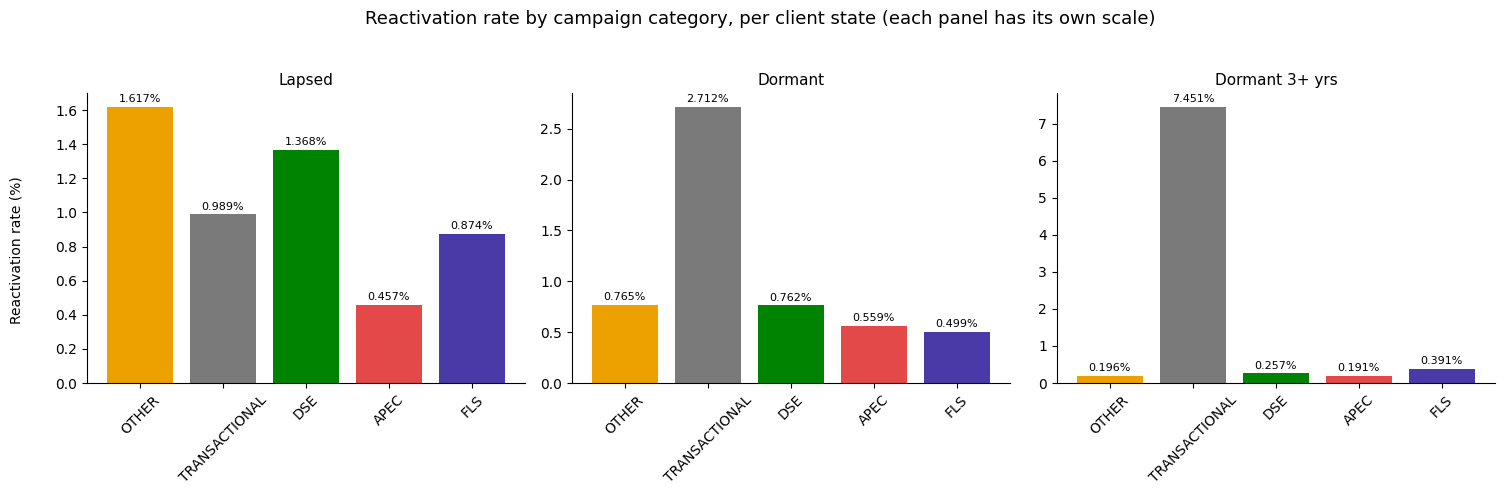

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, state in enumerate(LIFECYCLE_STATES):
    ax = axes[i]
    state_df = category_by_state_df[category_by_state_df['lifecycle_state'] == state].set_index('campaign_category').reindex(CATEGORY_ORDER)
    bars = ax.bar(
        CATEGORY_ORDER, state_df['client_reactivation_rate'] * 100,
        color=[CATEGORY_COLORS[c] for c in CATEGORY_ORDER],
    )
    ax.bar_label(bars, fmt='%.3f%%', fontsize=8, padding=2)
    ax.set_title(state, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', labelrotation=45)

fig.suptitle('Reactivation rate by campaign category, per client state (each panel has its own scale)', fontsize=13)
fig.text(0.0, 0.5, 'Reactivation rate (%)', va='center', rotation='vertical')
plt.tight_layout(rect=[0.02, 0, 1, 0.95])
plt.show()

### Full-window vs. per-month view, by client state

The chart above answers "of everyone ever sent this category in this state,
what fraction reactivated at least once across the whole window?" — a
client counts once, no matter how many months they were sent. That rewards
a category for simply having more chances to reach the same client: OTHER,
DSE, and APEC resend to nearly the same client base almost every month,
while FLS is triggered by a single high-intent event, so a given client
typically appears in FLS once or twice across the whole window, not every
month.

The table below adds a second unit, a **client-month** (one client, one
month, sent this category in this state), so a client sent in 8 different
months contributes 8, not 1. Comparing the two rates side by side shows
whether a category's full-window ranking is still true "per opportunity,"
or whether it's partly just a function of how often that category resends.

In [11]:
category_by_state_monthly_query = f"""--sql
WITH sends AS (
    SELECT client_id, sent_timestamp, send_utm_campaign, send_utm_content
    FROM blueshift.campaign_activity_kpis
    WHERE execution_date >= DATE '{START_DATE}'
      AND execution_date <= DATE '{END_DATE}'
      AND holdout_group = 0
),
state_at_send AS (
    SELECT
        s.client_id, s.sent_timestamp, s.send_utm_campaign, s.send_utm_content,
        CASE
            WHEN j.client_state_detail = 'Never Active' THEN 'Never Active'
            WHEN date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) <= {ACTIVE_MAX_DAYS} THEN 'Active'
            WHEN date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) <= {LAPSED_MAX_DAYS} THEN 'Lapsed'
            WHEN date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) <= {DORMANT_3YR_MIN_DAYS} THEN 'Dormant'
            ELSE 'Dormant 3+ yrs'
        END AS lifecycle_state
    FROM sends s
    INNER JOIN curated.checkout_based_client_state_journal j
        ON s.client_id = j.client_id
        AND s.sent_timestamp >= j.start_timestamp
        AND s.sent_timestamp <  j.end_timestamp
),
eligible_sends AS (
    SELECT * FROM state_at_send WHERE lifecycle_state NOT IN ('Never Active', 'Active')
),
categorized_sends AS (
    SELECT
        client_id, sent_timestamp, send_utm_content, lifecycle_state,
        CASE
            WHEN send_utm_campaign LIKE '%apec%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%browseabandon%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%stylepass%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%styleprofile%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%transactional%' THEN 'TRANSACTIONAL'
            WHEN regexp_like(send_utm_campaign, '(^|_)dse(_|$)') THEN 'DSE'
            WHEN send_utm_campaign LIKE '%tfy%' THEN 'DSE'
            WHEN send_utm_campaign LIKE '%cyl%' THEN 'DSE'
            WHEN send_utm_campaign LIKE '%offertest%' THEN 'OTHER'
            WHEN send_utm_campaign LIKE '%freestyle-lifecycle%' THEN 'FLS'
            WHEN send_utm_campaign LIKE '%freestyle_lifecycle%' THEN 'FLS'
            ELSE 'OTHER'
        END AS campaign_category
    FROM eligible_sends
),
matched_sessions AS (
    SELECT c.client_id, c.sent_timestamp, c.lifecycle_state, c.campaign_category, u.active_session_id
    FROM categorized_sends c
    INNER JOIN curated.user_session_conversion_metrics u
        ON u.client_id = c.client_id
        AND u.utm_source = 'blueshift'
        AND u.utm_content = c.send_utm_content
        AND u.datetime_in_utc >= c.sent_timestamp
        AND u.datetime_in_utc <  c.sent_timestamp + INTERVAL '{SESSION_ATTRIBUTION_WINDOW_DAYS}' DAY
    WHERE u.date_in_utc >= DATE '{START_DATE}'
),
attributed_demand AS (
    SELECT DISTINCT ms.client_id, ms.sent_timestamp, ms.lifecycle_state, ms.campaign_category
    FROM matched_sessions ms
    INNER JOIN curated.client_reactivation_demand_events e
        ON e.active_session_id = ms.active_session_id
    WHERE e.demand_type IN ('fix', 'direct_buy')
),
client_month_category AS (
    SELECT
        d.client_id,
        DATE_TRUNC('month', d.sent_timestamp) AS month,
        d.lifecycle_state,
        d.campaign_category,
        MAX(CASE WHEN a.client_id IS NOT NULL THEN 1 ELSE 0 END) AS client_reactivated
    FROM categorized_sends d
    LEFT JOIN attributed_demand a
        ON d.client_id = a.client_id
        AND d.sent_timestamp = a.sent_timestamp
        AND d.lifecycle_state = a.lifecycle_state
        AND d.campaign_category = a.campaign_category
    GROUP BY 1, 2, 3, 4
)
SELECT
    month,
    lifecycle_state,
    campaign_category,
    COUNT(DISTINCT client_id) AS unique_clients_sent,
    SUM(client_reactivated) AS reactivated_clients,
    CAST(SUM(client_reactivated) AS DOUBLE) / COUNT(DISTINCT client_id) AS client_reactivation_rate
FROM client_month_category
GROUP BY 1, 2, 3
ORDER BY 2, 3, 1
"""

category_by_state_monthly_df = query(category_by_state_monthly_query)
category_by_state_monthly_df['month'] = pd.to_datetime(category_by_state_monthly_df['month'])
category_by_state_monthly_df.head()

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,month,lifecycle_state,campaign_category,unique_clients_sent,reactivated_clients,client_reactivation_rate
0,2025-01-01,Dormant,APEC,654858,942,0.001438
1,2025-02-01,Dormant,APEC,638675,616,0.000964
2,2025-03-01,Dormant,APEC,633085,557,0.000880
3,2025-04-01,Dormant,APEC,617866,465,0.000753
4,2025-05-01,Dormant,APEC,604722,708,0.001171


In [12]:
category_by_state_monthly_totals = category_by_state_monthly_df.groupby(['lifecycle_state', 'campaign_category']).agg(
    client_months_sent=('unique_clients_sent', 'sum'),
    reactivated_month_sum=('reactivated_clients', 'sum'),
).reset_index()
category_by_state_monthly_totals['reactivation_rate_per_month'] = (
    category_by_state_monthly_totals['reactivated_month_sum'] / category_by_state_monthly_totals['client_months_sent']
)

state_full_vs_monthly = category_by_state_df[['lifecycle_state', 'campaign_category', 'unique_clients_sent', 'reactivated_clients', 'client_reactivation_rate']] \
    .merge(category_by_state_monthly_totals, on=['lifecycle_state', 'campaign_category']) \
    .sort_values(['lifecycle_state', 'unique_clients_sent'], ascending=[True, False])
state_full_vs_monthly

,lifecycle_state,campaign_category,unique_clients_sent,reactivated_clients,client_reactivation_rate,client_months_sent,reactivated_month_sum,reactivation_rate_per_month
0,Dormant,OTHER,2577880,19722,0.007650,15825266,19864,0.001255
1,Dormant,DSE,1657056,12625,0.007619,13220511,12689,0.000960
2,Dormant,APEC,1142669,6393,0.005595,7327138,6421,0.000876
3,Dormant,TRANSACTIONAL,782892,21232,0.027120,1021384,21463,0.021014
4,Dormant,FLS,88929,444,0.004993,169983,447,0.002630
5,Dormant 3+ yrs,OTHER,4295781,8416,0.001959,25458014,8457,0.000332
6,Dormant 3+ yrs,DSE,1846336,4740,0.002567,19901339,4752,0.000239
7,Dormant 3+ yrs,APEC,1355921,2590,0.001910,11088071,2600,0.000234
8,Dormant 3+ yrs,TRANSACTIONAL,586498,43700,0.074510,717086,43968,0.061315
9,Dormant 3+ yrs,FLS,36294,142,0.003912,64221,144,0.002242


## Part 3 — Business line: Women's, Men's, and Kids

The same two comparisons as Parts 1 and 2 — APEC vs. non-APEC, and the full
category breakdown — now cut by business line instead of lifecycle state,
with all three lifecycle states pooled together (business line is evaluated
as its own, independent lens rather than crossed with state, to avoid
splitting an already-rare event across too many small sub-populations).

Business line comes from `curated.client.business_line`, joined by
`client_id` — the client's own account attribute, not something inferred
from the campaign's name. Clients with a null business line are excluded.

In [13]:
apec_by_bizline_query = f"""--sql
WITH sends AS (
    SELECT client_id, sent_timestamp, send_utm_campaign, send_utm_content
    FROM blueshift.campaign_activity_kpis
    WHERE execution_date >= DATE '{START_DATE}'
      AND execution_date <= DATE '{END_DATE}'
      AND holdout_group = 0
      AND send_utm_campaign NOT LIKE '%transactional%'
),
eligible_sends AS (
    -- same eligibility as Parts 1-2, states pooled: must not be Never Active or Active AS OF the send
    SELECT s.client_id, s.sent_timestamp, s.send_utm_campaign, s.send_utm_content
    FROM sends s
    INNER JOIN curated.checkout_based_client_state_journal j
        ON s.client_id = j.client_id
        AND s.sent_timestamp >= j.start_timestamp
        AND s.sent_timestamp <  j.end_timestamp
    WHERE j.client_state_detail != 'Never Active'
      AND date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) > {ACTIVE_MAX_DAYS}
),
business_line_sends AS (
    SELECT e.client_id, e.sent_timestamp, e.send_utm_campaign, e.send_utm_content, c.business_line
    FROM eligible_sends e
    INNER JOIN curated.client c ON e.client_id = c.client_id
    WHERE c.business_line IN {BUSINESS_LINES}
),
categorized_sends AS (
    SELECT
        client_id, sent_timestamp, send_utm_content, business_line,
        CASE
            WHEN send_utm_campaign LIKE '%apec%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%browseabandon%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%stylepass%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%styleprofile%' THEN 'APEC'
            ELSE 'non-APEC'
        END AS apec_group
    FROM business_line_sends
),
matched_sessions AS (
    SELECT c.client_id, c.sent_timestamp, c.business_line, c.apec_group, u.active_session_id
    FROM categorized_sends c
    INNER JOIN curated.user_session_conversion_metrics u
        ON u.client_id = c.client_id
        AND u.utm_source = 'blueshift'
        AND u.utm_content = c.send_utm_content
        AND u.datetime_in_utc >= c.sent_timestamp
        AND u.datetime_in_utc <  c.sent_timestamp + INTERVAL '{SESSION_ATTRIBUTION_WINDOW_DAYS}' DAY
    WHERE u.date_in_utc >= DATE '{START_DATE}'
),
attributed_demand AS (
    SELECT DISTINCT ms.client_id, ms.sent_timestamp, ms.business_line, ms.apec_group
    FROM matched_sessions ms
    INNER JOIN curated.client_reactivation_demand_events e
        ON e.active_session_id = ms.active_session_id
    WHERE e.demand_type IN ('fix', 'direct_buy')
),
client_group AS (
    SELECT
        d.client_id, d.business_line, d.apec_group,
        MAX(CASE WHEN a.client_id IS NOT NULL THEN 1 ELSE 0 END) AS client_reactivated
    FROM categorized_sends d
    LEFT JOIN attributed_demand a
        ON d.client_id = a.client_id
        AND d.sent_timestamp = a.sent_timestamp
        AND d.business_line = a.business_line
        AND d.apec_group = a.apec_group
    GROUP BY 1, 2, 3
)
SELECT
    business_line,
    apec_group,
    COUNT(DISTINCT client_id) AS unique_clients_sent,
    SUM(client_reactivated) AS reactivated_clients,
    CAST(SUM(client_reactivated) AS DOUBLE) / COUNT(DISTINCT client_id) AS client_reactivation_rate
FROM client_group
GROUP BY 1, 2
ORDER BY 1, 2
"""

apec_by_bizline_df = query(apec_by_bizline_query)
apec_by_bizline_df

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,business_line,apec_group,unique_clients_sent,reactivated_clients,client_reactivation_rate
0,Kids,non-APEC,458232,1852,0.004042
1,Mens,APEC,555599,2373,0.004271
2,Mens,non-APEC,1325887,10598,0.007993
3,Womens,APEC,2025516,9427,0.004654
4,Womens,non-APEC,5721192,89033,0.015562


In [14]:
apec_by_bizline_summary = summarize_apec_vs_non_apec(apec_by_bizline_df, 'business_line', list(BUSINESS_LINES))
print_apec_summary(apec_by_bizline_summary, 'business_line')
apec_by_bizline_summary

--- Womens ---
  APEC:      0.4654%  (95% CI: 0.4561% - 0.4749%, n=2,025,516)
  non-APEC:  1.5562%  (95% CI: 1.5461% - 1.5664%, n=5,721,192)
  Difference (non-APEC minus APEC): 1.0908%  (95% CI: 1.0770% - 1.1046%)
  p-value: 0.00e+00

--- Mens ---
  APEC:      0.4271%  (95% CI: 0.4103% - 0.4446%, n=555,599)
  non-APEC:  0.7993%  (95% CI: 0.7843% - 0.8146%, n=1,325,887)
  Difference (non-APEC minus APEC): 0.3722%  (95% CI: 0.3493% - 0.3951%)
  p-value: 5.79e-223

--- Kids ---
  APEC:      no qualifying sends observed in this group
  non-APEC:  0.4042%  (95% CI: 0.3862% - 0.4230%, n=458,232)
  Difference/test: not computable -- one side has no qualifying sends



,business_line,apec_n,apec_rate,apec_ci_low,apec_ci_high,non_apec_n,non_apec_rate,non_apec_ci_low,non_apec_ci_high,diff_non_apec_minus_apec,diff_ci_low,diff_ci_high,p_value
0,Womens,2025516,0.004654,0.004561,0.004749,5721192,0.015562,0.015461,0.015664,0.010908,0.010770,0.011046,0.000000e+00
1,Mens,555599,0.004271,0.004103,0.004446,1325887,0.007993,0.007843,0.008146,0.003722,0.003493,0.003951,5.792144e-223
2,Kids,0,NaN,NaN,NaN,458232,0.004042,0.003862,0.004230,NaN,NaN,NaN,NaN


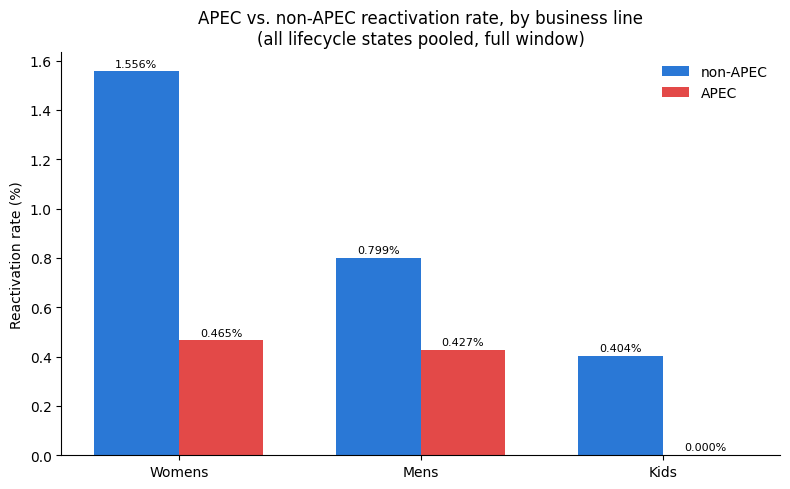

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(BUSINESS_LINES))
width = 0.35

bizline_indexed = apec_by_bizline_summary.set_index('business_line')

def rate_or_zero(b, col):
    # 0-height bar for a business line with zero qualifying sends on that side (e.g. Kids x APEC)
    if b not in bizline_indexed.index or pd.isna(bizline_indexed.loc[b, col]):
        return 0
    return bizline_indexed.loc[b, col] * 100

non_apec_rates = [rate_or_zero(b, 'non_apec_rate') for b in BUSINESS_LINES]
apec_rates = [rate_or_zero(b, 'apec_rate') for b in BUSINESS_LINES]

bars_non_apec = ax.bar([i - width/2 for i in x], non_apec_rates, width, label='non-APEC', color=GROUP_COLORS['non-APEC'])
bars_apec = ax.bar([i + width/2 for i in x], apec_rates, width, label='APEC', color=GROUP_COLORS['APEC'])

for bars in (bars_non_apec, bars_apec):
    ax.bar_label(bars, fmt='%.3f%%', fontsize=8, padding=2)

ax.set_xticks(list(x))
ax.set_xticklabels(BUSINESS_LINES)
ax.set_ylabel('Reactivation rate (%)')
ax.set_title('APEC vs. non-APEC reactivation rate, by business line\n(all lifecycle states pooled, full window)')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [16]:
category_by_bizline_query = f"""--sql
WITH sends AS (
    SELECT client_id, sent_timestamp, send_utm_campaign, send_utm_content
    FROM blueshift.campaign_activity_kpis
    WHERE execution_date >= DATE '{START_DATE}'
      AND execution_date <= DATE '{END_DATE}'
      AND holdout_group = 0
),
eligible_sends AS (
    SELECT s.client_id, s.sent_timestamp, s.send_utm_campaign, s.send_utm_content
    FROM sends s
    INNER JOIN curated.checkout_based_client_state_journal j
        ON s.client_id = j.client_id
        AND s.sent_timestamp >= j.start_timestamp
        AND s.sent_timestamp <  j.end_timestamp
    WHERE j.client_state_detail != 'Never Active'
      AND date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) > {ACTIVE_MAX_DAYS}
),
business_line_sends AS (
    SELECT e.client_id, e.sent_timestamp, e.send_utm_campaign, e.send_utm_content, c.business_line
    FROM eligible_sends e
    INNER JOIN curated.client c ON e.client_id = c.client_id
    WHERE c.business_line IN {BUSINESS_LINES}
),
categorized_sends AS (
    SELECT
        client_id, sent_timestamp, send_utm_content, business_line,
        CASE
            WHEN send_utm_campaign LIKE '%apec%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%browseabandon%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%stylepass%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%styleprofile%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%transactional%' THEN 'TRANSACTIONAL'
            WHEN regexp_like(send_utm_campaign, '(^|_)dse(_|$)') THEN 'DSE'
            WHEN send_utm_campaign LIKE '%tfy%' THEN 'DSE'
            WHEN send_utm_campaign LIKE '%cyl%' THEN 'DSE'
            WHEN send_utm_campaign LIKE '%offertest%' THEN 'OTHER'
            WHEN send_utm_campaign LIKE '%freestyle-lifecycle%' THEN 'FLS'
            WHEN send_utm_campaign LIKE '%freestyle_lifecycle%' THEN 'FLS'
            ELSE 'OTHER'
        END AS campaign_category
    FROM business_line_sends
),
matched_sessions AS (
    SELECT c.client_id, c.sent_timestamp, c.business_line, c.campaign_category, u.active_session_id
    FROM categorized_sends c
    INNER JOIN curated.user_session_conversion_metrics u
        ON u.client_id = c.client_id
        AND u.utm_source = 'blueshift'
        AND u.utm_content = c.send_utm_content
        AND u.datetime_in_utc >= c.sent_timestamp
        AND u.datetime_in_utc <  c.sent_timestamp + INTERVAL '{SESSION_ATTRIBUTION_WINDOW_DAYS}' DAY
    WHERE u.date_in_utc >= DATE '{START_DATE}'
),
attributed_demand AS (
    SELECT DISTINCT ms.client_id, ms.sent_timestamp, ms.business_line, ms.campaign_category
    FROM matched_sessions ms
    INNER JOIN curated.client_reactivation_demand_events e
        ON e.active_session_id = ms.active_session_id
    WHERE e.demand_type IN ('fix', 'direct_buy')
),
client_category AS (
    SELECT
        d.client_id, d.business_line, d.campaign_category,
        MAX(CASE WHEN a.client_id IS NOT NULL THEN 1 ELSE 0 END) AS client_reactivated
    FROM categorized_sends d
    LEFT JOIN attributed_demand a
        ON d.client_id = a.client_id
        AND d.sent_timestamp = a.sent_timestamp
        AND d.business_line = a.business_line
        AND d.campaign_category = a.campaign_category
    GROUP BY 1, 2, 3
)
SELECT
    business_line,
    campaign_category,
    COUNT(DISTINCT client_id) AS unique_clients_sent,
    SUM(client_reactivated) AS reactivated_clients,
    CAST(SUM(client_reactivated) AS DOUBLE) / COUNT(DISTINCT client_id) AS client_reactivation_rate
FROM client_category
GROUP BY 1, 2
ORDER BY 1, unique_clients_sent DESC
"""

category_by_bizline_df = query(category_by_bizline_query)
category_by_bizline_df

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,business_line,campaign_category,unique_clients_sent,reactivated_clients,client_reactivation_rate
0,Kids,OTHER,458232,1852,0.004042
1,Kids,TRANSACTIONAL,142612,720,0.005049
2,Mens,OTHER,1324227,6877,0.005193
3,Mens,DSE,757258,3890,0.005137
4,Mens,APEC,559666,2417,0.004319
5,Mens,TRANSACTIONAL,425141,5913,0.013908
6,Mens,FLS,15690,89,0.005672
7,Womens,OTHER,5701100,54625,0.009581
8,Womens,DSE,3191888,36082,0.011304
9,Womens,APEC,2058709,9916,0.004817


In [17]:
category_by_bizline_df[['ci_low', 'ci_high']] = category_by_bizline_df.apply(
    lambda r: pd.Series(proportion_confint(r['reactivated_clients'], r['unique_clients_sent'], alpha=ALPHA, method='wilson')),
    axis=1,
)
category_by_bizline_df['rate_display'] = category_by_bizline_df.apply(
    lambda r: f"{r['client_reactivation_rate']:.4%}  ({r['ci_low']:.4%} - {r['ci_high']:.4%})", axis=1
)

category_by_bizline_pivot = category_by_bizline_df.pivot(index='campaign_category', columns='business_line', values='rate_display')
category_by_bizline_pivot = category_by_bizline_pivot.reindex(CATEGORY_ORDER)[list(BUSINESS_LINES)]
category_by_bizline_pivot

business_line,Womens,Mens,Kids
campaign_category,,,
OTHER,0.9581% (0.9502% - 0.9662%),0.5193% (0.5072% - 0.5317%),0.4042% (0.3862% - 0.4230%)
TRANSACTIONAL,3.6030% (3.5774% - 3.6287%),1.3908% (1.3561% - 1.4265%),0.5049% (0.4694% - 0.5430%)
DSE,1.1304% (1.1189% - 1.1421%),0.5137% (0.4978% - 0.5300%),NaN
APEC,0.4817% (0.4723% - 0.4912%),0.4319% (0.4150% - 0.4494%),NaN
FLS,0.7893% (0.7562% - 0.8238%),0.5672% (0.4612% - 0.6975%),NaN


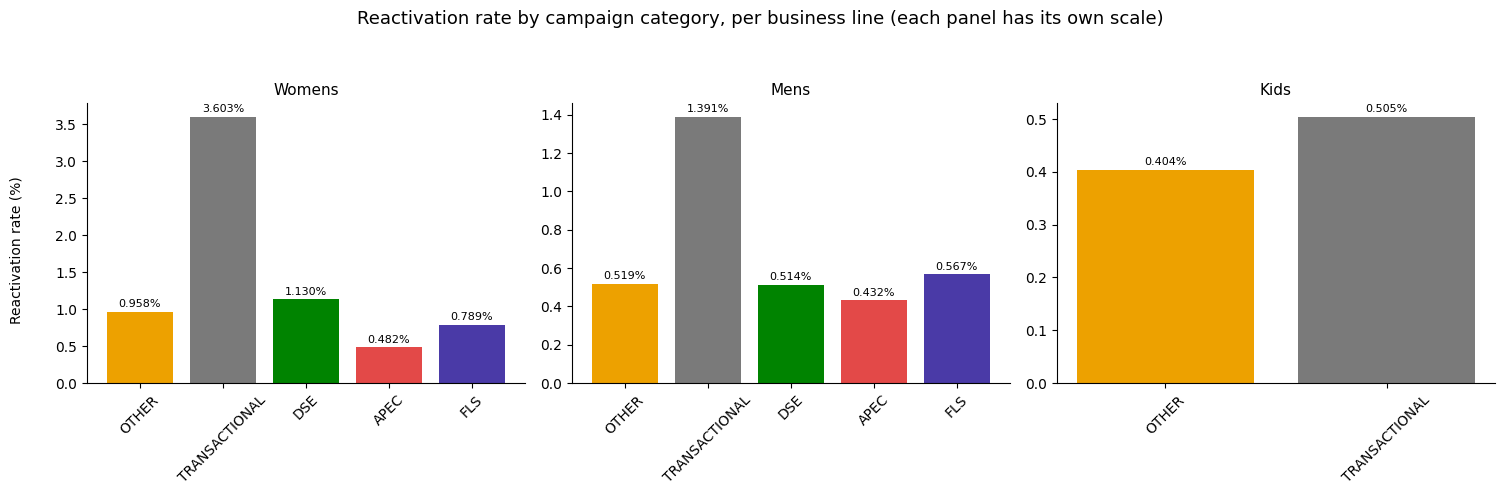

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, bizline in enumerate(BUSINESS_LINES):
    ax = axes[i]
    bizline_df = category_by_bizline_df[category_by_bizline_df['business_line'] == bizline].set_index('campaign_category').reindex(CATEGORY_ORDER)
    bars = ax.bar(
        CATEGORY_ORDER, bizline_df['client_reactivation_rate'] * 100,
        color=[CATEGORY_COLORS[c] for c in CATEGORY_ORDER],
    )
    ax.bar_label(bars, fmt='%.3f%%', fontsize=8, padding=2)
    ax.set_title(bizline, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', labelrotation=45)

fig.suptitle('Reactivation rate by campaign category, per business line (each panel has its own scale)', fontsize=13)
fig.text(0.0, 0.5, 'Reactivation rate (%)', va='center', rotation='vertical')
plt.tight_layout(rect=[0.02, 0, 1, 0.93])
plt.show()

### Full-window vs. per-month view, by business line

Same idea as the client-state breakdown above, now for business line: the
chart's full-window rate counts a client once no matter how many months
they were sent, which favors categories that resend often (OTHER, DSE,
APEC) over one that only fires on a single triggering event (FLS). The
table below re-expresses the same data per **client-month** instead, so the
comparison controls for how often each category actually resends.

In [19]:
category_by_bizline_monthly_query = f"""--sql
WITH sends AS (
    SELECT client_id, sent_timestamp, send_utm_campaign, send_utm_content
    FROM blueshift.campaign_activity_kpis
    WHERE execution_date >= DATE '{START_DATE}'
      AND execution_date <= DATE '{END_DATE}'
      AND holdout_group = 0
),
eligible_sends AS (
    SELECT s.client_id, s.sent_timestamp, s.send_utm_campaign, s.send_utm_content
    FROM sends s
    INNER JOIN curated.checkout_based_client_state_journal j
        ON s.client_id = j.client_id
        AND s.sent_timestamp >= j.start_timestamp
        AND s.sent_timestamp <  j.end_timestamp
    WHERE j.client_state_detail != 'Never Active'
      AND date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) > {ACTIVE_MAX_DAYS}
),
business_line_sends AS (
    SELECT e.client_id, e.sent_timestamp, e.send_utm_campaign, e.send_utm_content, c.business_line
    FROM eligible_sends e
    INNER JOIN curated.client c ON e.client_id = c.client_id
    WHERE c.business_line IN {BUSINESS_LINES}
),
categorized_sends AS (
    SELECT
        client_id, sent_timestamp, send_utm_content, business_line,
        CASE
            WHEN send_utm_campaign LIKE '%apec%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%browseabandon%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%stylepass%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%styleprofile%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%transactional%' THEN 'TRANSACTIONAL'
            WHEN regexp_like(send_utm_campaign, '(^|_)dse(_|$)') THEN 'DSE'
            WHEN send_utm_campaign LIKE '%tfy%' THEN 'DSE'
            WHEN send_utm_campaign LIKE '%cyl%' THEN 'DSE'
            WHEN send_utm_campaign LIKE '%offertest%' THEN 'OTHER'
            WHEN send_utm_campaign LIKE '%freestyle-lifecycle%' THEN 'FLS'
            WHEN send_utm_campaign LIKE '%freestyle_lifecycle%' THEN 'FLS'
            ELSE 'OTHER'
        END AS campaign_category
    FROM business_line_sends
),
matched_sessions AS (
    SELECT c.client_id, c.sent_timestamp, c.business_line, c.campaign_category, u.active_session_id
    FROM categorized_sends c
    INNER JOIN curated.user_session_conversion_metrics u
        ON u.client_id = c.client_id
        AND u.utm_source = 'blueshift'
        AND u.utm_content = c.send_utm_content
        AND u.datetime_in_utc >= c.sent_timestamp
        AND u.datetime_in_utc <  c.sent_timestamp + INTERVAL '{SESSION_ATTRIBUTION_WINDOW_DAYS}' DAY
    WHERE u.date_in_utc >= DATE '{START_DATE}'
),
attributed_demand AS (
    SELECT DISTINCT ms.client_id, ms.sent_timestamp, ms.business_line, ms.campaign_category
    FROM matched_sessions ms
    INNER JOIN curated.client_reactivation_demand_events e
        ON e.active_session_id = ms.active_session_id
    WHERE e.demand_type IN ('fix', 'direct_buy')
),
client_month_category AS (
    SELECT
        d.client_id,
        DATE_TRUNC('month', d.sent_timestamp) AS month,
        d.business_line,
        d.campaign_category,
        MAX(CASE WHEN a.client_id IS NOT NULL THEN 1 ELSE 0 END) AS client_reactivated
    FROM categorized_sends d
    LEFT JOIN attributed_demand a
        ON d.client_id = a.client_id
        AND d.sent_timestamp = a.sent_timestamp
        AND d.business_line = a.business_line
        AND d.campaign_category = a.campaign_category
    GROUP BY 1, 2, 3, 4
)
SELECT
    month,
    business_line,
    campaign_category,
    COUNT(DISTINCT client_id) AS unique_clients_sent,
    SUM(client_reactivated) AS reactivated_clients,
    CAST(SUM(client_reactivated) AS DOUBLE) / COUNT(DISTINCT client_id) AS client_reactivation_rate
FROM client_month_category
GROUP BY 1, 2, 3
ORDER BY 2, 3, 1
"""

category_by_bizline_monthly_df = query(category_by_bizline_monthly_query)
category_by_bizline_monthly_df['month'] = pd.to_datetime(category_by_bizline_monthly_df['month'])
category_by_bizline_monthly_df.head()

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,month,business_line,campaign_category,unique_clients_sent,reactivated_clients,client_reactivation_rate
0,2025-01-01,Kids,OTHER,323940,257,0.000793
1,2025-02-01,Kids,OTHER,310382,151,0.000486
2,2025-03-01,Kids,OTHER,288391,78,0.000270
3,2025-04-01,Kids,OTHER,288654,170,0.000589
4,2025-05-01,Kids,OTHER,66981,54,0.000806


In [20]:
category_by_bizline_monthly_totals = category_by_bizline_monthly_df.groupby(['business_line', 'campaign_category']).agg(
    client_months_sent=('unique_clients_sent', 'sum'),
    reactivated_month_sum=('reactivated_clients', 'sum'),
).reset_index()
category_by_bizline_monthly_totals['reactivation_rate_per_month'] = (
    category_by_bizline_monthly_totals['reactivated_month_sum'] / category_by_bizline_monthly_totals['client_months_sent']
)

bizline_full_vs_monthly = category_by_bizline_df[['business_line', 'campaign_category', 'unique_clients_sent', 'reactivated_clients', 'client_reactivation_rate']] \
    .merge(category_by_bizline_monthly_totals, on=['business_line', 'campaign_category']) \
    .sort_values(['business_line', 'unique_clients_sent'], ascending=[True, False])
bizline_full_vs_monthly

,business_line,campaign_category,unique_clients_sent,reactivated_clients,client_reactivation_rate,client_months_sent,reactivated_month_sum,reactivation_rate_per_month
0,Kids,OTHER,458232,1852,0.004042,4494478,1918,0.000427
1,Kids,TRANSACTIONAL,142612,720,0.005049,268200,761,0.002837
2,Mens,OTHER,1324227,6877,0.005193,9064252,7150,0.000789
3,Mens,DSE,757258,3890,0.005137,7759883,3984,0.000513
4,Mens,APEC,559666,2417,0.004319,5964546,2461,0.000413
5,Mens,TRANSACTIONAL,425141,5913,0.013908,663012,5989,0.009033
6,Mens,FLS,15690,89,0.005672,25515,90,0.003527
7,Womens,OTHER,5701100,54625,0.009581,37684584,57541,0.001527
8,Womens,DSE,3191888,36082,0.011304,33563663,37572,0.001119
9,Womens,APEC,2058709,9916,0.004817,14463731,10005,0.000692


## Category reactivation trend over time, all states combined

One more view of Part 2's category breakdown: OTHER, DSE, APEC, and FLS
plotted together on a single shared-scale chart across the full analysis
window, with all three lifecycle states pooled (same eligible
population used in Part 3). TRANSACTIONAL is left out of this chart, not the
underlying data -- its rate is roughly two orders of magnitude above the
other four (see Part 2), so sharing an axis with it would flatten every
other line to near-zero.

In [21]:
category_monthly_query = f"""--sql
WITH sends AS (
    SELECT client_id, sent_timestamp, send_utm_campaign, send_utm_content
    FROM blueshift.campaign_activity_kpis
    WHERE execution_date >= DATE '{START_DATE}'
      AND execution_date <= DATE '{END_DATE}'
      AND holdout_group = 0
),
eligible_sends AS (
    SELECT s.client_id, s.sent_timestamp, s.send_utm_campaign, s.send_utm_content
    FROM sends s
    INNER JOIN curated.checkout_based_client_state_journal j
        ON s.client_id = j.client_id
        AND s.sent_timestamp >= j.start_timestamp
        AND s.sent_timestamp <  j.end_timestamp
    WHERE j.client_state_detail != 'Never Active'
      AND date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) > {ACTIVE_MAX_DAYS}
),
categorized_sends AS (
    SELECT
        client_id, sent_timestamp, send_utm_content,
        CASE
            WHEN send_utm_campaign LIKE '%apec%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%browseabandon%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%stylepass%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%styleprofile%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%transactional%' THEN 'TRANSACTIONAL'
            WHEN regexp_like(send_utm_campaign, '(^|_)dse(_|$)') THEN 'DSE'
            WHEN send_utm_campaign LIKE '%tfy%' THEN 'DSE'
            WHEN send_utm_campaign LIKE '%cyl%' THEN 'DSE'
            WHEN send_utm_campaign LIKE '%offertest%' THEN 'OTHER'
            WHEN send_utm_campaign LIKE '%freestyle-lifecycle%' THEN 'FLS'
            WHEN send_utm_campaign LIKE '%freestyle_lifecycle%' THEN 'FLS'
            ELSE 'OTHER'
        END AS campaign_category
    FROM eligible_sends
),
matched_sessions AS (
    SELECT c.client_id, c.sent_timestamp, c.campaign_category, u.active_session_id
    FROM categorized_sends c
    INNER JOIN curated.user_session_conversion_metrics u
        ON u.client_id = c.client_id
        AND u.utm_source = 'blueshift'
        AND u.utm_content = c.send_utm_content
        AND u.datetime_in_utc >= c.sent_timestamp
        AND u.datetime_in_utc <  c.sent_timestamp + INTERVAL '{SESSION_ATTRIBUTION_WINDOW_DAYS}' DAY
    WHERE u.date_in_utc >= DATE '{START_DATE}'
),
attributed_demand AS (
    SELECT DISTINCT ms.client_id, ms.sent_timestamp, ms.campaign_category
    FROM matched_sessions ms
    INNER JOIN curated.client_reactivation_demand_events e
        ON e.active_session_id = ms.active_session_id
    WHERE e.demand_type IN ('fix', 'direct_buy')
),
client_month_category AS (
    SELECT
        d.client_id,
        DATE_TRUNC('month', d.sent_timestamp) AS month,
        d.campaign_category,
        MAX(CASE WHEN a.client_id IS NOT NULL THEN 1 ELSE 0 END) AS client_reactivated
    FROM categorized_sends d
    LEFT JOIN attributed_demand a
        ON d.client_id = a.client_id
        AND d.sent_timestamp = a.sent_timestamp
        AND d.campaign_category = a.campaign_category
    GROUP BY 1, 2, 3
)
SELECT
    month,
    campaign_category,
    COUNT(DISTINCT client_id) AS unique_clients_sent,
    SUM(client_reactivated) AS reactivated_clients,
    CAST(SUM(client_reactivated) AS DOUBLE) / COUNT(DISTINCT client_id) AS client_reactivation_rate
FROM client_month_category
GROUP BY 1, 2
ORDER BY 2, 1
"""

category_monthly_df = query(category_monthly_query)
category_monthly_df['month'] = pd.to_datetime(category_monthly_df['month'])
category_monthly_df.head()

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,month,campaign_category,unique_clients_sent,reactivated_clients,client_reactivation_rate
0,2025-01-01,APEC,1743593,1837,0.001054
1,2025-02-01,APEC,1650923,1135,0.000687
2,2025-03-01,APEC,1636503,1059,0.000647
3,2025-04-01,APEC,1615859,948,0.000587
4,2025-05-01,APEC,1595278,1341,0.000841


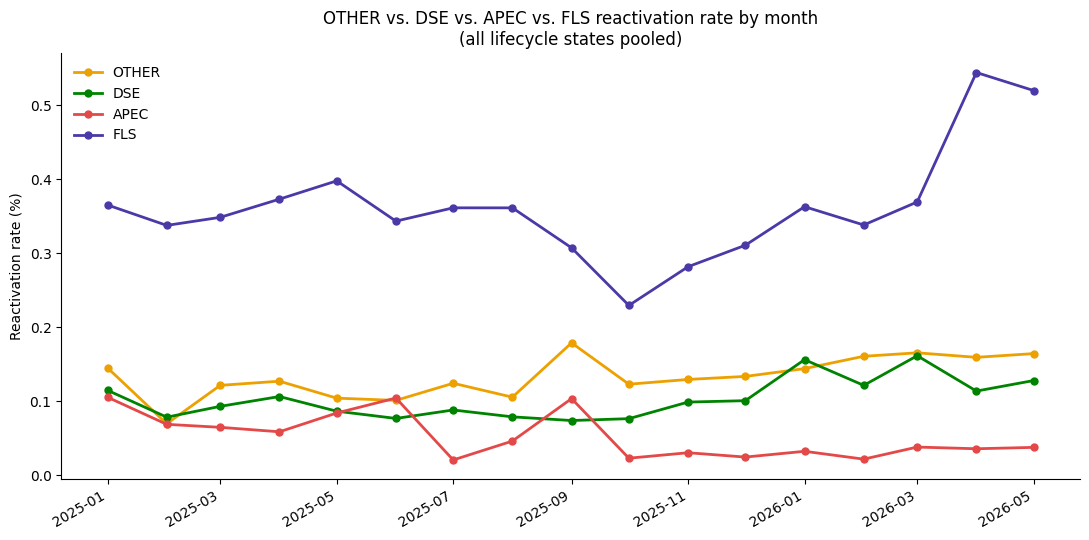

In [22]:
fig, ax = plt.subplots(figsize=(11, 5.5))

for cat in ['OTHER', 'DSE', 'APEC', 'FLS']:
    cat_df = category_monthly_df[category_monthly_df['campaign_category'] == cat].sort_values('month')
    ax.plot(
        cat_df['month'], cat_df['client_reactivation_rate'] * 100,
        marker='o', markersize=5, linewidth=2,
        color=CATEGORY_COLORS[cat], label=cat,
    )

ax.set_ylabel('Reactivation rate (%)')
ax.set_xlabel('')
ax.set_title('OTHER vs. DSE vs. APEC vs. FLS reactivation rate by month\n(all lifecycle states pooled)')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Category reactivation trend over time, by client state

The same four categories, now split into one panel per client state instead
of pooling everyone together. This checks whether a category's trend --
and its ranking relative to the others -- holds consistently within each
state on its own, rather than being an artifact of one state's volume
dominating the pooled view above. This reuses the same monthly-by-state
data already fetched for the full-window-vs-per-month comparison earlier.

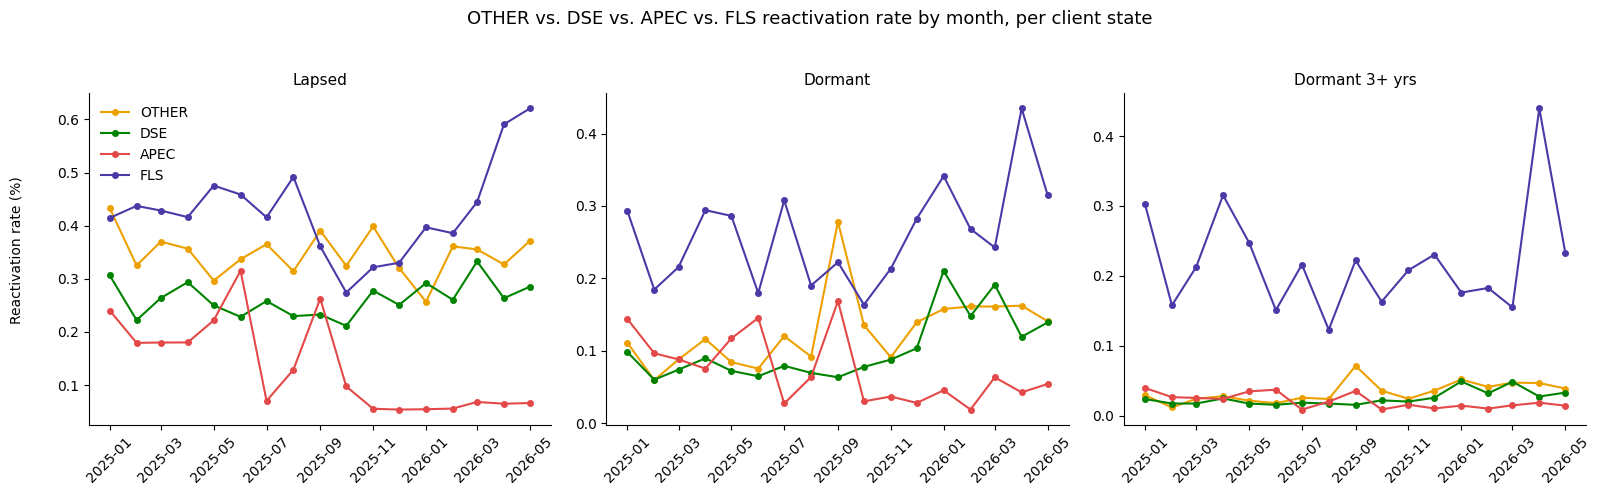

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True)

for i, state in enumerate(LIFECYCLE_STATES):
    ax = axes[i]
    state_df = category_by_state_monthly_df[category_by_state_monthly_df['lifecycle_state'] == state]
    for cat in ['OTHER', 'DSE', 'APEC', 'FLS']:
        cat_df = state_df[state_df['campaign_category'] == cat].sort_values('month')
        ax.plot(
            cat_df['month'], cat_df['client_reactivation_rate'] * 100,
            marker='o', markersize=4, linewidth=1.5,
            color=CATEGORY_COLORS[cat], label=cat,
        )
    ax.set_title(state, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', labelrotation=45)

axes[0].legend(frameon=False)
fig.suptitle('OTHER vs. DSE vs. APEC vs. FLS reactivation rate by month, per client state', fontsize=13)
fig.text(0.0, 0.5, 'Reactivation rate (%)', va='center', rotation='vertical')
plt.tight_layout(rect=[0.02, 0, 1, 0.95])
plt.show()

## Limitations to keep in mind

- **Observational, not causal.** Nothing here is randomized. If APEC and
  non-APEC sends go to different sub-segments of a population, are sent at
  different frequencies, or through different channels, some of any observed
  gap could reflect those differences rather than personalization itself.
- **The reactivation metric is a lower bound.** It only counts reactivation
  with click-through evidence (a UTM-matched session). Real reactivations
  that happen through untracked paths aren't counted. This affects every
  state and business line, not just one, but the *size* of that undercount
  could differ across them if engagement patterns (e.g. app vs. email usage)
  differ by group.
- **Transactional/account-service email is excluded from Parts 1 and 3, and
  called out separately in Parts 2 and 3's category breakdowns, because it
  isn't a marketing lever.** A client only receives one of these because
  they're already taking an action on their own account — the reactivation
  credited to it reflects the client's own return, not something the send
  caused.
- **DSE and FLS use their own personalization/triggering logic, distinct
  from APEC's.** DSE dynamically assembles shoppable product content; FLS is
  triggered by high-intent client behaviors like cart abandonment or saved
  items. Both are confirmed, well-defined campaign programs — the caveat is
  that neither reflects APEC's personalization mechanism, so their results
  are context on the broader campaign landscape, not evidence about APEC
  specifically.
- **The FLS/OTHER boundary is name-based and imperfect.** Only campaigns
  with an explicit "freestyle-lifecycle" naming convention are counted as
  FLS; other Freestyle-branded content that references specific clothing
  themes but lacks that identifier falls into OTHER. FLS's reported volume
  and rate should be read as a lower bound on true Freestyle Lifecycle
  Series activity.
- **A one-time mass reactivation test is excluded from FLS.** A broad
  lapsed-client win-back offer test (campaign names containing "offertest")
  shares FLS's naming convention but wasn't a behaviorally-triggered send —
  it's routed to OTHER instead, ahead of the FLS check.
- **Business line is a current, client-level attribute, not a per-send
  target.** It's joined from `curated.client.business_line` by `client_id`,
  not re-evaluated as of each send's date the way lifecycle state is. If a
  client's business line ever changes over time, sends from earlier in the
  window are still attributed to their current business line.
- **APEC's near-absence in Kids is structural, not a data artifact.** The
  reference job-configuration list backing the APEC name-matching patterns
  (`apec_setup_doc.xlsx`) contains zero Kids-targeted campaigns — so a
  near-zero or zero APEC reactivation rate in the Kids business line
  reflects that APEC campaigns generally aren't sent to Kids clients, not a
  gap in this notebook's matching logic.
- **Campaign-name-based classification is inherently approximate.** No
  per-send flag confirms a campaign's true category; this relies on pattern
  matching against `send_utm_campaign`, validated against a reference list
  for APEC specifically, but not independently verified for DSE, FLS, or
  OTHER.
- **`END_DATE` relies on a 45-day maturity assumption that is not
  independently confirmed** for this notebook's data sources
  (`user_session_conversion_metrics`, `client_reactivation_demand_events`) —
  the most recent 1-2 months in this window deserve slightly more caution
  than the rest.